In [1]:
import pandas as pd 
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

train_data = pd.read_parquet('../data/processed/train_woe.parquet')
oot_data = pd.read_parquet('../data/processed/oot_woe.parquet')

In [5]:
X_train = train_data.drop(columns=['TARGET'])
y_train = train_data['TARGET']

X_oot = oot_data.drop(columns=['TARGET'])
y_oot = oot_data['TARGET']

In [10]:
log_reg = LogisticRegression(max_iter=1000, random_state=42, penalty='l2')
log_reg.fit(X_train, y_train)

y_train_pred = log_reg.predict(X_train)
y_oot_pred = log_reg.predict(X_oot)

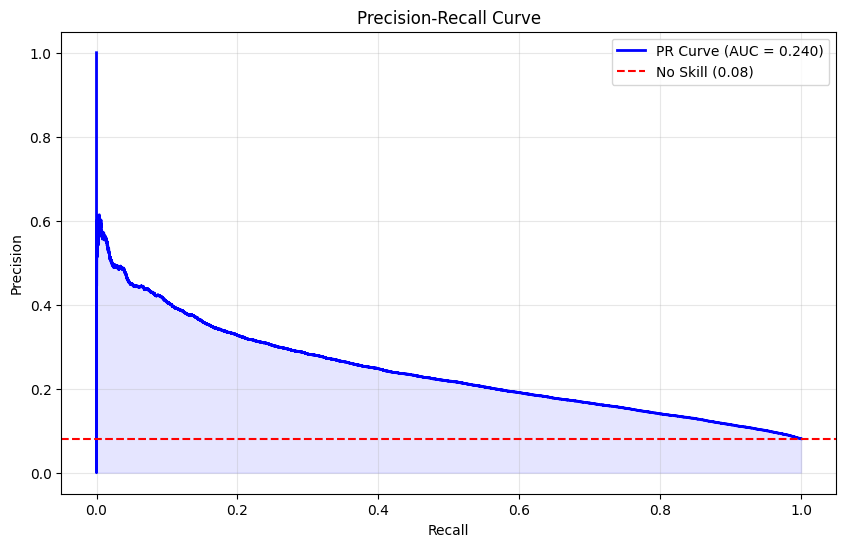

In [16]:
y_train_pred_proba = log_reg.predict_proba(X_train)[:, 1]

from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_train, y_train_pred_proba)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AUC = {pr_auc:.3f})')
plt.fill_between(recall, precision, alpha=0.1, color='blue')

# No-skill baseline (доля позитивных классов)
baseline = y_train.mean()
plt.axhline(y=baseline, color='red', linestyle='--', label=f'No Skill ({baseline:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()

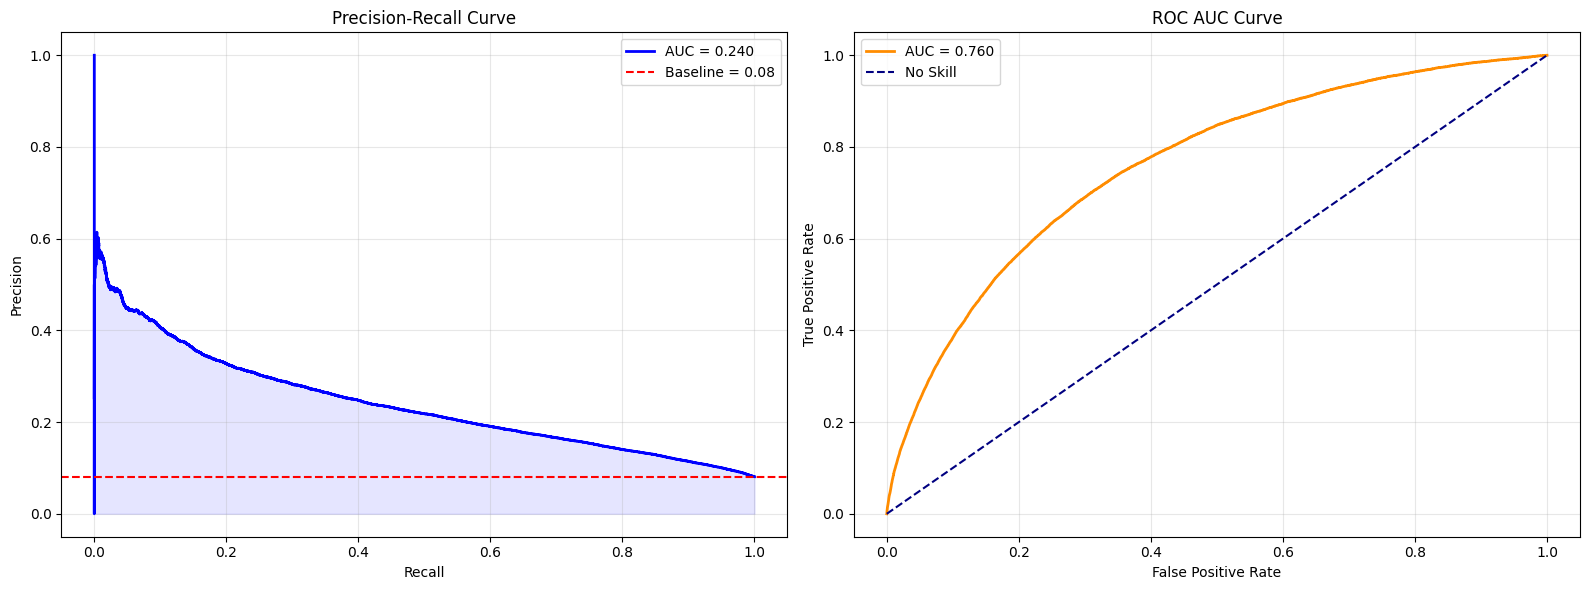

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


from sklearn.metrics import roc_curve, roc_auc_score
# PR Curve
precision, recall, thresholds_pr = precision_recall_curve(y_train, y_train_pred_proba)
pr_auc = auc(recall, precision)
axes[0].plot(recall, precision, color='blue', lw=2, label=f'AUC = {pr_auc:.3f}')
axes[0].fill_between(recall, precision, alpha=0.1, color='blue')
axes[0].axhline(y=y_train.mean(), color='red', linestyle='--', label=f'Baseline = {y_train.mean():.2f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# ROC Curve
fpr, tpr, _ = roc_curve(y_train, y_train_pred_proba)
roc_auc = roc_auc_score(y_train, y_train_pred_proba)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], color='navy', linestyle='--', label='No Skill')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC AUC Curve')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
print(metrics.classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96    226148
           1       0.51      0.02      0.04     19860

    accuracy                           0.92    246008
   macro avg       0.72      0.51      0.50    246008
weighted avg       0.89      0.92      0.88    246008



In [19]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import pandas as pd

precision, recall, thresholds = precision_recall_curve(y_train, y_train_pred_proba)

f1 = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-9)

best_idx = np.argmax(f1)
best_threshold = thresholds[best_idx]
best_precision = precision[best_idx]
best_recall = recall[best_idx]
best_f1 = f1[best_idx]

pd.DataFrame({
    'best_threshold': [best_threshold],
    'precision': [best_precision],
    'recall': [best_recall],
    'f1': [best_f1]
})

,best_threshold,precision,recall,f1
0,0.142808,0.234006,0.444411,0.306581


In [20]:
y_train_pred_new = (y_train_pred_proba >= best_threshold).astype(int)
print(metrics.classification_report(y_train, y_train_pred_new))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91    226148
           1       0.23      0.44      0.31     19860

    accuracy                           0.84    246008
   macro avg       0.59      0.66      0.61    246008
weighted avg       0.89      0.84      0.86    246008

